# Set Up

In [1]:
%run SetUp/SetUp.ipynb
%run SetUp/Process_Data-wModule.ipynb
%run SetUp/graph_helper.ipynb

Home Directory = /Users/cjpar01/Work/WFE/wfey
Log Path = /Users/cjpar01/Work/WFE/wfey/logs/new_cores_and_param_run/
Home Directory = /Users/cjpar01/Work/WFE/wfey
Log Path = /Users/cjpar01/Work/WFE/wfey/logs/new_cores_and_param_run/
SKIPPING: /Users/cjpar01/Work/WFE/wfey/logs/new_cores_and_param_run/busypoll_nodb/50000_1_10_0/latency-2026-06-29-13-38-44.out --- Problem parsing latency numbers ( No columns to parse from file )
all columns:  Index(['KEY', 'configs', 'eventrate', 'eventprocCPUs', 'sourceCPUs',
       'workpercs', 'SRC_ID', 'WorkType', 'Latency_Min', 'Latency_Max',
       'Latency_Mean', 'apparentPower', 'current', 'realPower',
       'currentCrestFactor', 'voltage', 'energy', 'powerFactor', 'epThread',
       'ID', 'Core', 'TimeRan', 'Start Energy', 'End Energy', 'Energy Diff',
       'Total Wakeups', 'Spurious Wakeups', 'Events', 'Active Cycles',
       'Inactive Cycles', 'Cycle Diff', 'CPU Cycles', 'Instructions Retired'],
      dtype='object')
Event Rate subset:  [0, 50

In [2]:
palette_y1 = ["#7209B7"] # purple
palette_y2 = ["#4CC9F0"] # blue

## On Beast

### Busypoll WithOUT Doorbell

##### 1 Event Source, 1 Event Processor

Event Rate subset:  [0, 50000]
Source CPU subset:  [1, 10]
Procesor CPU subset:  [1]
Work Perc (mem) subset:  [0, 100]


<Figure size 640x480 with 0 Axes>

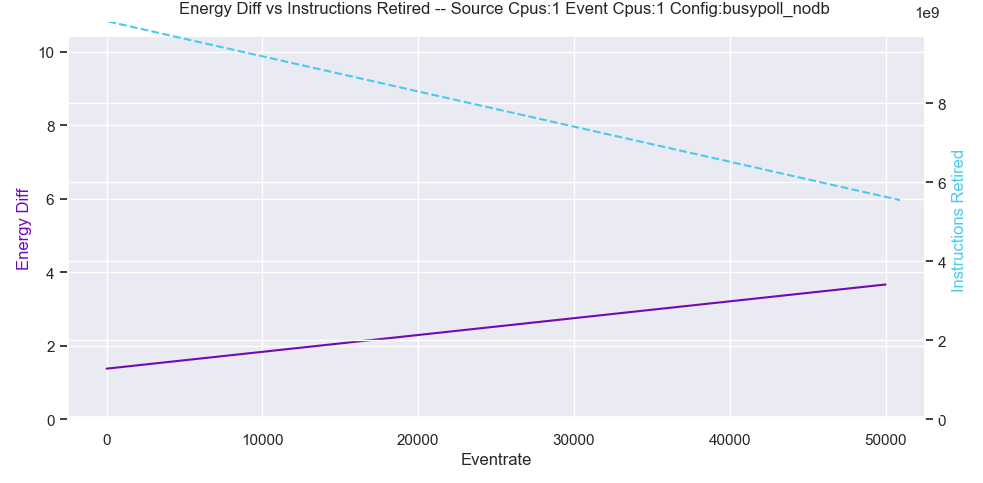

<Figure size 640x480 with 0 Axes>

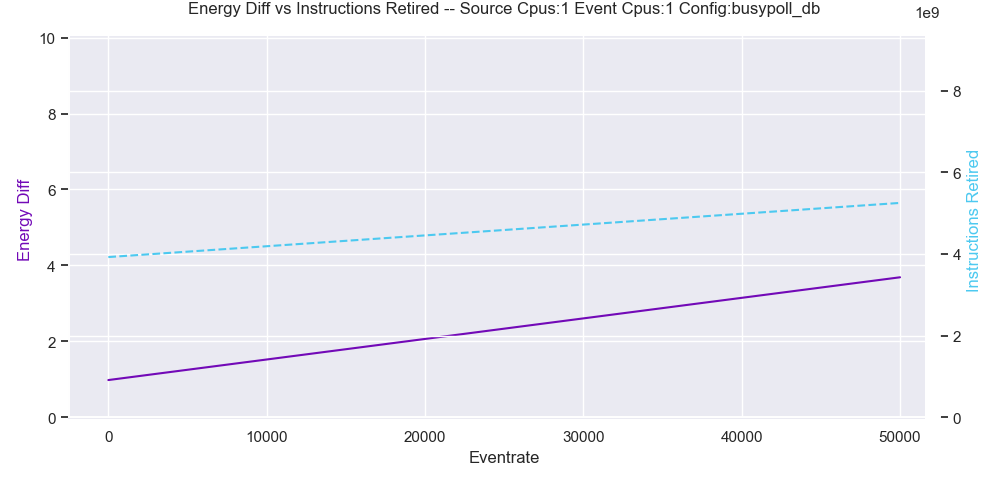

<Figure size 640x480 with 0 Axes>

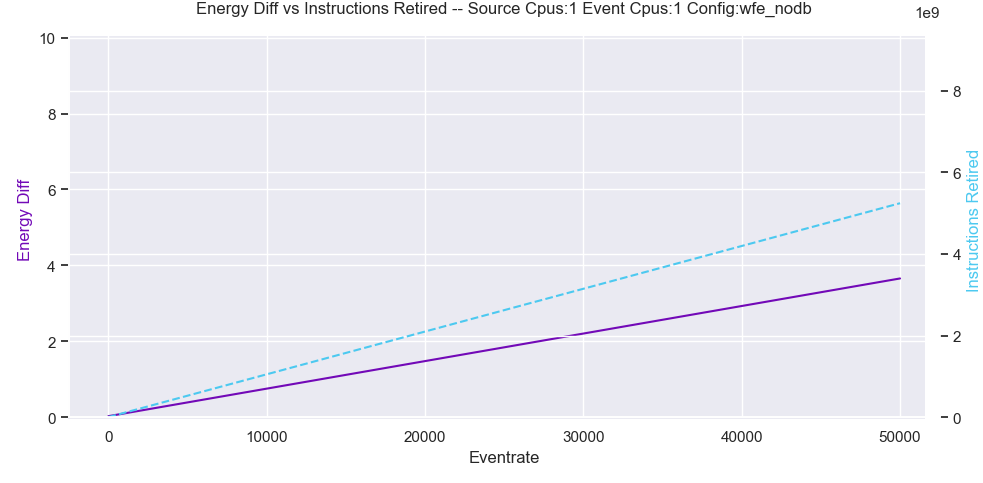

<Figure size 640x480 with 0 Axes>

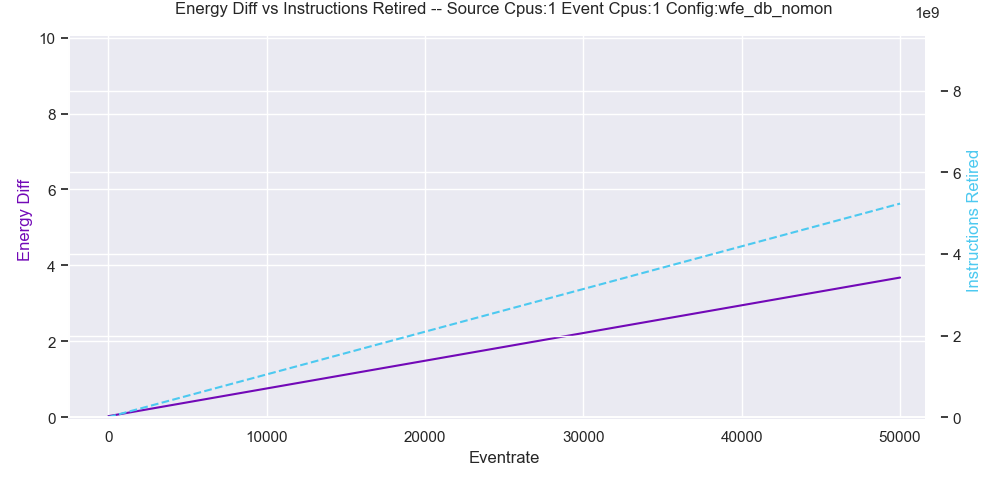

<Figure size 640x480 with 0 Axes>

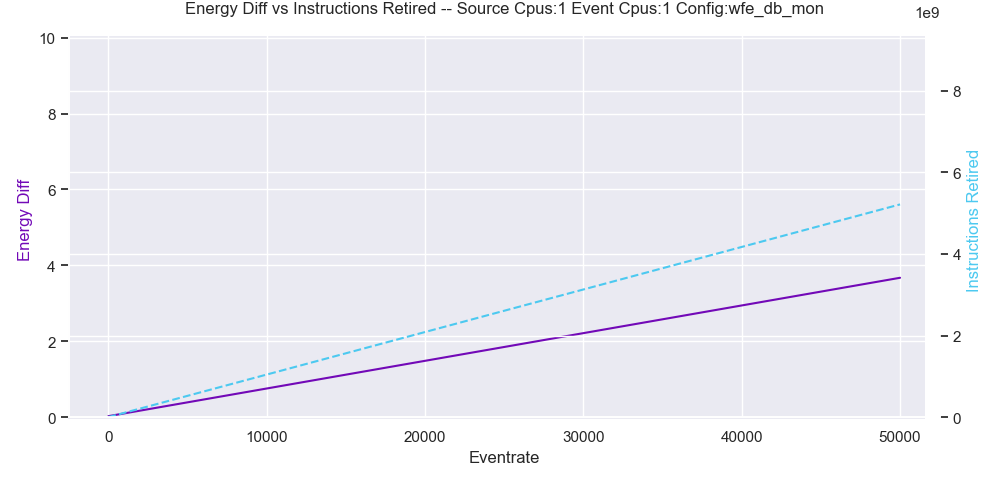

<Figure size 640x480 with 0 Axes>

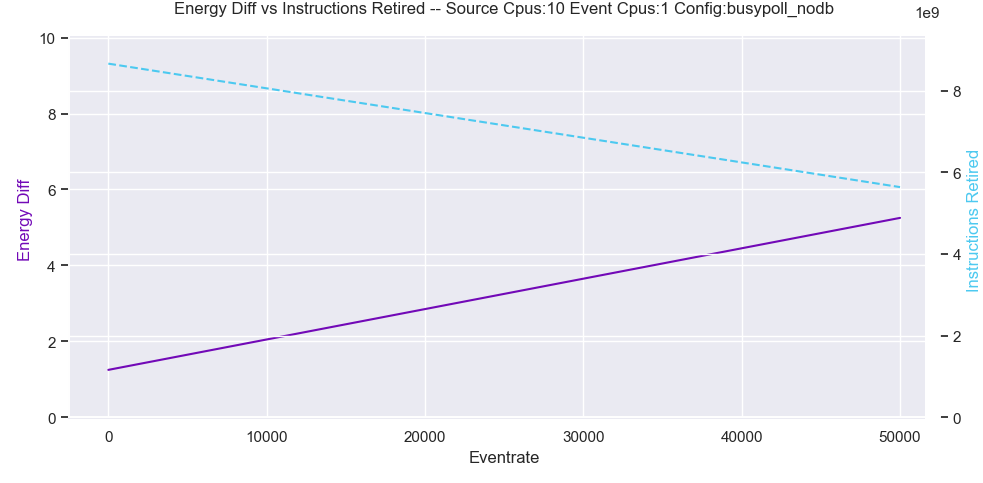

<Figure size 640x480 with 0 Axes>

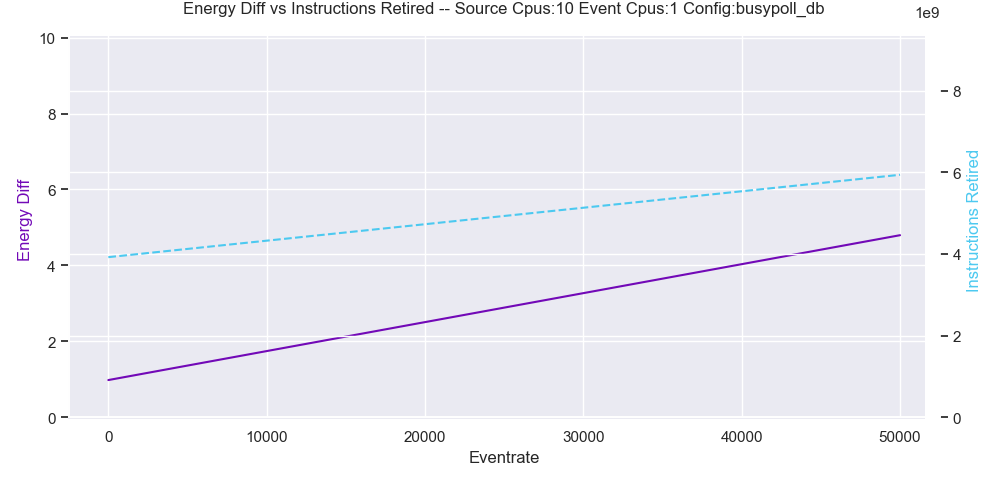

<Figure size 640x480 with 0 Axes>

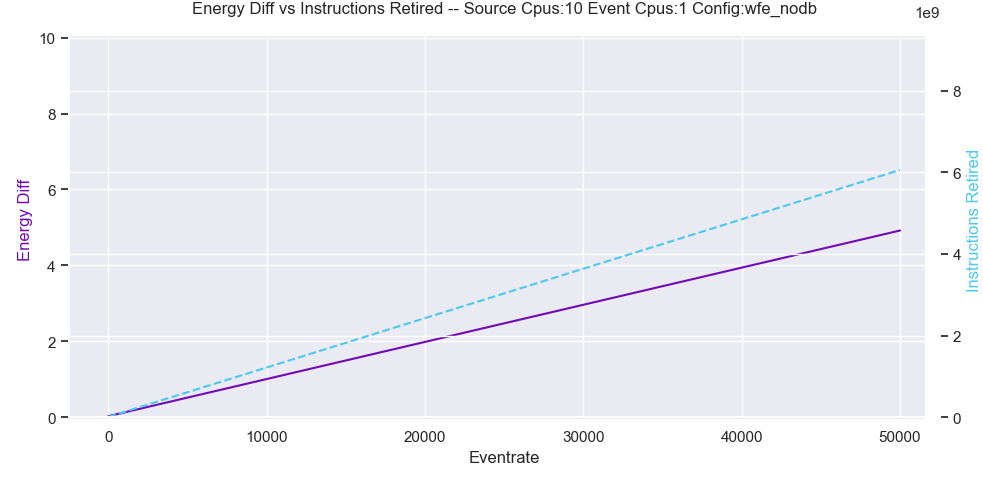

<Figure size 640x480 with 0 Axes>

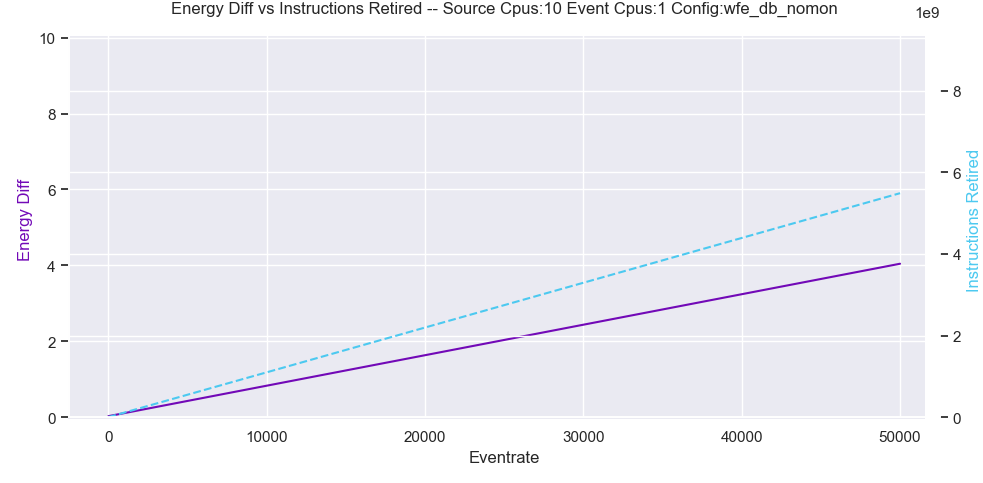

<Figure size 640x480 with 0 Axes>

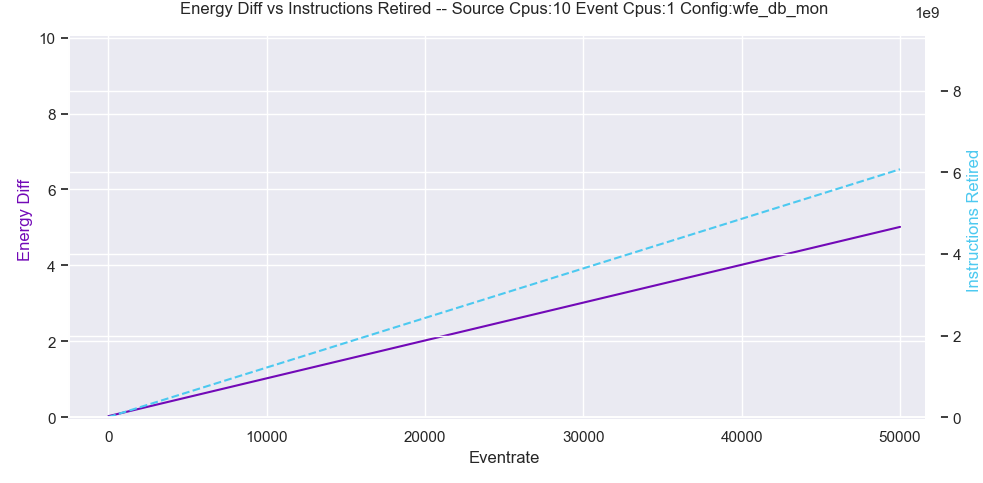

In [3]:
df_used = return_df(bm_perf_output_flat)
config_set = None

for proc in procsubset:
    for sc in sourceCPUsubset:
        for conf in CONFIGS:

            plt.figure()
            config_set = df_used[(df_used['eventprocCPUs'] == proc) & (df_used['sourceCPUs'] == sc) & (df_used['configs'] == conf)]
            #print(config_set)
            
            fig, ax1 = plt.subplots(figsize=(10, 5))
            
            sns.lineplot(
                data=config_set, 
                x='eventrate',
                y=ENERGY_COLUMN,
                ax=ax1,
                legend=False,
                hue=ax1,
                palette=palette_y1,
                errorbar=None,
                markers=True,
            )
            ax2 = ax1.twinx()
            
            sns.lineplot(
                data=config_set, 
                x='eventrate',
                y=bm_var_to_compare,
                ax=ax2,
                legend=False,
                hue=ax1,
                palette=palette_y2,
                errorbar=None,
                linestyle='--',
                markers=True
            )
            
            
            plt.title(ENERGY_COLUMN+' vs ' + bm_var_to_compare + ' -- Source Cpus:'+str(sc) +' Event Cpus:'+str(proc) +' Config:'+str(conf) )
            ax1.set_xlabel('Eventrate')
            ax1.set_ylabel(ENERGY_COLUMN , color=palette_y1[0])
            ax2.set_ylabel(bm_var_to_compare, color=palette_y2[0])
            ax1.set_ylim(0,(df_used[ENERGY_COLUMN].max())+1) 
            ax2.set_ylim(0,(df_used[bm_var_to_compare].max()))
            
            plt.tight_layout()